In [ ]:
# data tools and plotting

from feature_eng import TSFE
import logging
import warnings
import os
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=PerformanceWarning)

#====================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000);
#=========================
#=============== feature engineering and define the needed features

feature_cols= [#'datetime', 
  #'tamb',  'pamb' ,
  #'psamp',
  'type',
  'pflow', 'tmod',  'CH4_rt', 'CH4_w',
       'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time',
       'CH4_start_level', 'CH4_end_level', #'duration', 
       'is_air','is_std',
       #'previous_type_std', 'previous_type_air','next_type_std', 'next_type_air', 
       ]

feature_config ={
    'diff':{'cols': ['CH4_area', 
                    'CH4_ht','CH4_w' , 'CH4_rt' #'tmod',#'CH4_end_time','CH4_start_time',,'CH4_rt'
                ], 'periods':[1, 3, 6, 72]},

    'lag':{'cols':['CH4_area', 'CH4_rt',  'CH4_ht', #'tmod',  'psamp','pamb','tamb',,'CH4_skew'
                'pflow',
              'CH4_w'], 'periods':[1, 3, 6, 72]},

    'diff_cross':{'cols':[['CH4_ht', 'CH4_ht_lag_72'],
                          ['CH4_area', 'CH4_area_lag_72'],
                          ['CH4_end_time', 'CH4_start_time'],
                      # ['CH4_w_roll_mean_2h', 'CH4_w_roll_mean_7h'],
                        ['CH4_end_level', 'CH4_start_level'],
                        ['CH4_rt', 'pflow'],
                        #['CH4_ht', 'CH4_ht_lag_72'],['CH4_w', 'CH4_w_lag_72'],
                        #['pflow', 'pflow_lag_1'],['CH4_skew','CH4_skew_lag_1']
                        ]}, 

    'roll_std':{'cols': ['CH4_w', 'CH4_ht','CH4_area', 'CH4_end_time_CH4_start_time_diff_cross'], 'period':['1h','3h','6h', '24h', '3D', '7D']},

    'roll_mean_percent_res':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area',], 'period': ['1h','3h','6h','24h', '3D', '7D']},



    #'log':{'cols':['last_std_CH4_ht','last_air_CH4_ht'
                   #'CH4_end_time', 
     #              ]},
     'roll_median':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area', 'pflow','CH4_area_lag_72','CH4_ht_lag_72'], 'period':['1h','3h','6h', '24h', '3D', '7D']},
     'roll_mad':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area', 'pflow'], 'period':['1h','3h','6h', '24h', '3D', '7D']},
     'roll_median_percent_res':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area','pflow','CH4_area_lag_72','CH4_ht_lag_72'],
                              'period':['1h','3h','6h', '24h', '3D', '7D']},

   # 'multi':{'cols':[['CH4_w', 'CH4_ht'],['CH4_area', 'pflow']]},

    'ratio':{'cols':[   ['CH4_skew','CH4_w'],
                        ['CH4_ht', 'pflow'],
                        ['CH4_ht', 'CH4_w'],
                        ['CH4_area', 'pflow'],
                        ['CH4_rt', 'pflow'],
                        ['CH4_ht', 'CH4_area'],
                        ['CH4_w', 'CH4_end_time_CH4_start_time_diff_cross'],
                       # ['CH4_rt', 'CH4_end_time_CH4_start_time_diff_cross'],

                       # ['CH4_ht', 'last_air_ht'],
                        #['CH4_w_roll_std_2h', 'CH4_w_roll_std_1D'],
                      
                        ['CH4_start_level', 'CH4_end_level'],
                  
                        ['CH4_w_roll_std_3h', 'CH4_w_roll_mean_3h'], ['CH4_ht_roll_std_3h', 'CH4_ht_roll_mean_3h'],['CH4_area_roll_std_3h', 'CH4_area_roll_mean_3h'],
                        ['CH4_w_roll_std_24h', 'CH4_w_roll_mean_24h'], ['CH4_ht_roll_std_24h', 'CH4_ht_roll_mean_24h'],['CH4_area_roll_std_24h', 'CH4_area_roll_mean_24h'],
                        #['CH4_w_roll_std_6h', 'CH4_w_roll_mean_6h'], ['CH4_ht_roll_std_6h', 'CH4_ht_roll_mean_6h'],['CH4_area_roll_std_6h', 'CH4_area_roll_mean_6h'],
                        #['CH4_ht_roll_std_24h', 'CH4_ht_roll_mean_24h']
                       # ['CH4_w_roll_std_7h', 'CH4_w_roll_mean_7h'],['CH4_ht_roll_std_7h', 'CH4_ht_roll_mean_7h'],
                        #['CH4_w_roll_std_2D', 'CH4_w_roll_mean_2D'],['CH4_ht_roll_std_2D', 'CH4_ht_roll_mean_2D'],
                        #['CH4_rt', 'last_std_rt'],
                        
                       #['CH4_end_time', 'CH4_start_time'], ['CH4_area', 'pflow'],  ['CH4_skew', 'CH4_w'],['CH4_w', 'CH4_ht']
                       ]}, 


    'per_change':{'cols':[['CH4_ht_diff_1', 'CH4_ht_lag_1']]},
    'relative_per': {'cols': ['CH4_w', 'CH4_ht'], 'period':['2h','7h']},
    'Z_score_res':{'cols':[['CH4_w', 'CH4_w_roll_mean_3h', 'CH4_w_roll_std_3h', '3h'], #['CH4_end_time', 'CH4_end_time_roll_mean_7D', 'CH4_end_time_roll_std_7D', '7D']
                           ]},
    'per_rank': {'cols': ['CH4_w', 'CH4_skew','CH4_ht'], 'period':['7D']},


}

In [2]:
df = pd.read_csv('../data/processed/mhd_ch4_cnan_v1.csv', index_col= 'datetime')
df = df.drop(df[df['year']==2026].index)

df.columns.tolist()

['date',
 'time',
 'type',
 'sample',
 'standard',
 'port',
 'ht',
 'tmod',
 'tamb',
 'lab_temp',
 'pflow',
 'psamp',
 'ploop',
 'pamb',
 'CH4_rt',
 'CH4_w',
 'CH4_ht',
 'CH4_area',
 'CH4_skew',
 'CH4_start_time',
 'CH4_end_time',
 'CH4_start_level',
 'CH4_end_level',
 'CH4_Rl_ht',
 'CH4_Rl_a',
 'CH4_Rl',
 'CH4_norm_ht',
 'CH4_norm_a',
 'CH4_norm_w',
 'CH4_R_ht',
 'CH4_R_a',
 'CH4_R',
 'CH4_C_ht',
 'CH4_C_a',
 'CH4_C',
 'CH4_std_stdev',
 'CH4_std_rep',
 'CH4_Cstd',
 'CH4_flag_ht',
 'CH4_flag_a',
 'CH4_flag',
 'CH4_flag_p',
 'CH4_flag_ht_bin',
 'CH4_flag_a_bin',
 'label1',
 'datetime_str',
 'is_ht_999',
 'is_area_999',
 'is_rt_zero',
 'is_w_zero',
 'duration',
 'is_duration_spike',
 'baseline_drift',
 'ht_area_ratio',
 'last_std_time',
 'seconds_since_last_std',
 'type_std',
 'type_air',
 'type_tank',
 'type_blank',
 'type_cal',
 'type_other',
 'year',
 'month',
 'day',
 'hour',
 'minute',
 'seconds',
 'is_air',
 'is_std',
 'label_c_nan']

df[((df['CH4_flag_ht']=='B')|(df['CH4_flag_a']=='B'))]

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 777226 entries, 1994-02-16 14:29:00 to 2025-12-31 23:58:00
Data columns (total 71 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   date                    777226 non-null  int64  
 1   time                    777226 non-null  int64  
 2   type                    777226 non-null  object 
 3   sample                  777226 non-null  object 
 4   standard                777226 non-null  object 
 5   port                    777226 non-null  int64  
 6   ht                      777226 non-null  float64
 7   tmod                    672468 non-null  float64
 8   tamb                    672468 non-null  float64
 9   lab_temp                0 non-null       float64
 10  pflow                   775251 non-null  float64
 11  psamp                   775257 non-null  float64
 12  ploop                   0 non-null       float64
 13  pamb                    775198 non-null  float64

In [4]:
df.columns.tolist()

['date',
 'time',
 'type',
 'sample',
 'standard',
 'port',
 'ht',
 'tmod',
 'tamb',
 'lab_temp',
 'pflow',
 'psamp',
 'ploop',
 'pamb',
 'CH4_rt',
 'CH4_w',
 'CH4_ht',
 'CH4_area',
 'CH4_skew',
 'CH4_start_time',
 'CH4_end_time',
 'CH4_start_level',
 'CH4_end_level',
 'CH4_Rl_ht',
 'CH4_Rl_a',
 'CH4_Rl',
 'CH4_norm_ht',
 'CH4_norm_a',
 'CH4_norm_w',
 'CH4_R_ht',
 'CH4_R_a',
 'CH4_R',
 'CH4_C_ht',
 'CH4_C_a',
 'CH4_C',
 'CH4_std_stdev',
 'CH4_std_rep',
 'CH4_Cstd',
 'CH4_flag_ht',
 'CH4_flag_a',
 'CH4_flag',
 'CH4_flag_p',
 'CH4_flag_ht_bin',
 'CH4_flag_a_bin',
 'label1',
 'datetime_str',
 'is_ht_999',
 'is_area_999',
 'is_rt_zero',
 'is_w_zero',
 'duration',
 'is_duration_spike',
 'baseline_drift',
 'ht_area_ratio',
 'last_std_time',
 'seconds_since_last_std',
 'type_std',
 'type_air',
 'type_tank',
 'type_blank',
 'type_cal',
 'type_other',
 'year',
 'month',
 'day',
 'hour',
 'minute',
 'seconds',
 'is_air',
 'is_std',
 'label_c_nan']

#  Label1


#=====================ml PART

In [5]:
target ='label1'

In [6]:
X = df[feature_cols]
y = df[target]
split_idx = int(len(df)*0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


tscv = TimeSeriesSplit(n_splits=5)
print(X.columns)
X_train.head()

Index(['type', 'pflow', 'tmod', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area',
       'CH4_skew', 'CH4_start_time', 'CH4_end_time', 'CH4_start_level',
       'CH4_end_level', 'is_air', 'is_std'],
      dtype='object')


,type,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,is_air,is_std
datetime,,,,,,,,,,,,,,
1994-02-16 14:29:00,air,841.9,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0
1994-02-16 14:49:00,air,840.4,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0
1994-02-16 15:09:00,air,839.4,40.01,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,1,0
1994-02-16 15:29:00,air,839.6,40.00,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,1,0
1994-02-16 18:00:00,air,845.4,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0


In [8]:
from pulearn import ElkanotoPuClassifier
from sklearn.ensemble import RandomForestClassifier
tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)
X_train_final = tsfe.transform(X_train)

X_test_final = tsfe.transform(X_test)
X_train_final.columns.tolist()


['type',
 'pflow',
 'tmod',
 'CH4_rt',
 'CH4_w',
 'CH4_ht',
 'CH4_area',
 'CH4_skew',
 'CH4_start_time',
 'CH4_end_time',
 'CH4_start_level',
 'CH4_end_level',
 'is_air',
 'is_std',
 'last_std_CH4_ht',
 'last_air_CH4_ht',
 'last_std_CH4_area',
 'last_air_CH4_area',
 'last_std_CH4_rt',
 'last_air_CH4_rt',
 'last_std_CH4_start_level',
 'last_air_CH4_start_level',
 'CH4_ht_to_last_std_ratio',
 'CH4_ht_to_last_air_ratio',
 'CH4_area_to_last_std_ratio',
 'CH4_area_to_last_air_ratio',
 'CH4_rt_to_last_std_ratio',
 'CH4_rt_to_last_air_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_start_level_to_last_air_ratio',
 'duration_rt_ratio',
 'rt_position',
 'baseline_slope',
 'level_area_ratio',
 'CH4_area_diff_1',
 'CH4_area_diff_3',
 'CH4_area_diff_6',
 'CH4_area_diff_72',
 'CH4_ht_diff_1',
 'CH4_ht_diff_3',
 'CH4_ht_diff_6',
 'CH4_ht_diff_72',
 'CH4_w_diff_1',
 'CH4_w_diff_3',
 'CH4_w_diff_6',
 'CH4_w_diff_72',
 'CH4_rt_diff_1',
 'CH4_rt_diff_3',
 'CH4_rt_diff_6',
 'CH4_rt_diff_72',
 'CH4_ar

In [9]:
X_train_final, X_test_final = (X_train_final.drop(columns='type'), 
                               X_test_final.drop(columns='type'))

#selected_features = slected_col(X_train_final)
#X_train_final  = X_train_final [feature_ml]


#X_test_final  = X_test_final [feature_ml]


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier


n_bags = 5

# obtain positive and unlabled index
pos_idx = np.flatnonzero(y_train.to_numpy() == 1)
unl_idx = np.flatnonzero(y_train.to_numpy() == 0)

# obtain the number of positive and unlabeled data
number_pos = len(pos_idx)
print("Positive:", len(pos_idx))
print("Unlabeled:", len(unl_idx))

rng = np.random.default_rng(42)

feature_importances = []
models = []

for bag in range(n_bags):
    sampled_pos = pos_idx

    #select same number data of positive data from unlabeld data
    sampled_unl_idx = rng.choice(
        unl_idx,
        size=number_pos,
        replace=False
    )

    sampled_idx = np.concatenate([
        pos_idx,
        sampled_unl_idx
    ])


    rng.shuffle(sampled_idx)

    X_pu = X_train_final.iloc[sampled_idx]
    y_pu = y_train.iloc[sampled_idx]

    print(
        f"\n PU training data, Bag {bag +1}/{n_bags}"
        f"Positive = {(y_pu ==1).sum()}, "
        f"Unlabeled = {(y_pu == 0).sum()}"
    )

    base_rf = RandomForestClassifier(
        random_state=42+bag
    )

    base_rf.fit(X_pu, y_pu)

    models.append(base_rf)

    feature_importances.append(
        base_rf.feature_importances_
    )


Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/5Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/5Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/5Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/5Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/5Positive = 21442, Unlabeled = 21442


In [ ]:
importance_df = pd.DataFrame(
    feature_importances,
    columns=X_train_final.columns
)
importance_summary = pd.DataFrame({
    "Feature": X_train_final.columns,
    "importance_mean":importance_df.mean(axis=0),
    "importance_std": importance_df.std(axis=0),
    "importance_cv percent":(importance_df.std(axis=0) / importance_df.mean(axis=0))*100  #coefficient of variation
}).sort_values(
    "importance_mean", ascending=False
    )


importance_summary

,Feature,importance_mean,importance_std,importance_cv percent
CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio,CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio,0.025417,0.006835,26.892489
CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio,CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio,0.023745,0.010520,44.304926
CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio,CH4_area_roll_std_24h_CH4_area_roll_mean_24h_r...,0.022378,0.004526,20.223561
CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio,CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio,0.020234,0.005256,25.975454
rt_position,rt_position,0.019210,0.003169,16.494416
CH4_ht_to_last_std_ratio,CH4_ht_to_last_std_ratio,0.018943,0.009863,52.067897
CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio,CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio,0.018757,0.003281,17.490800
CH4_w_residual_6h,CH4_w_residual_6h,0.018216,0.003491,19.166445
CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio,CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio,0.017899,0.006602,36.882674
CH4_w_residual_3h,CH4_w_residual_3h,0.017309,0.006338,36.617991


if mean is high but cv is high also,
that means the importance of feature relys on what kind of sample selected
for example: CH4_w_residual_3h :top 7,  cv is 40.536725 -> importance highly relates to the data selected (may not be so stable)

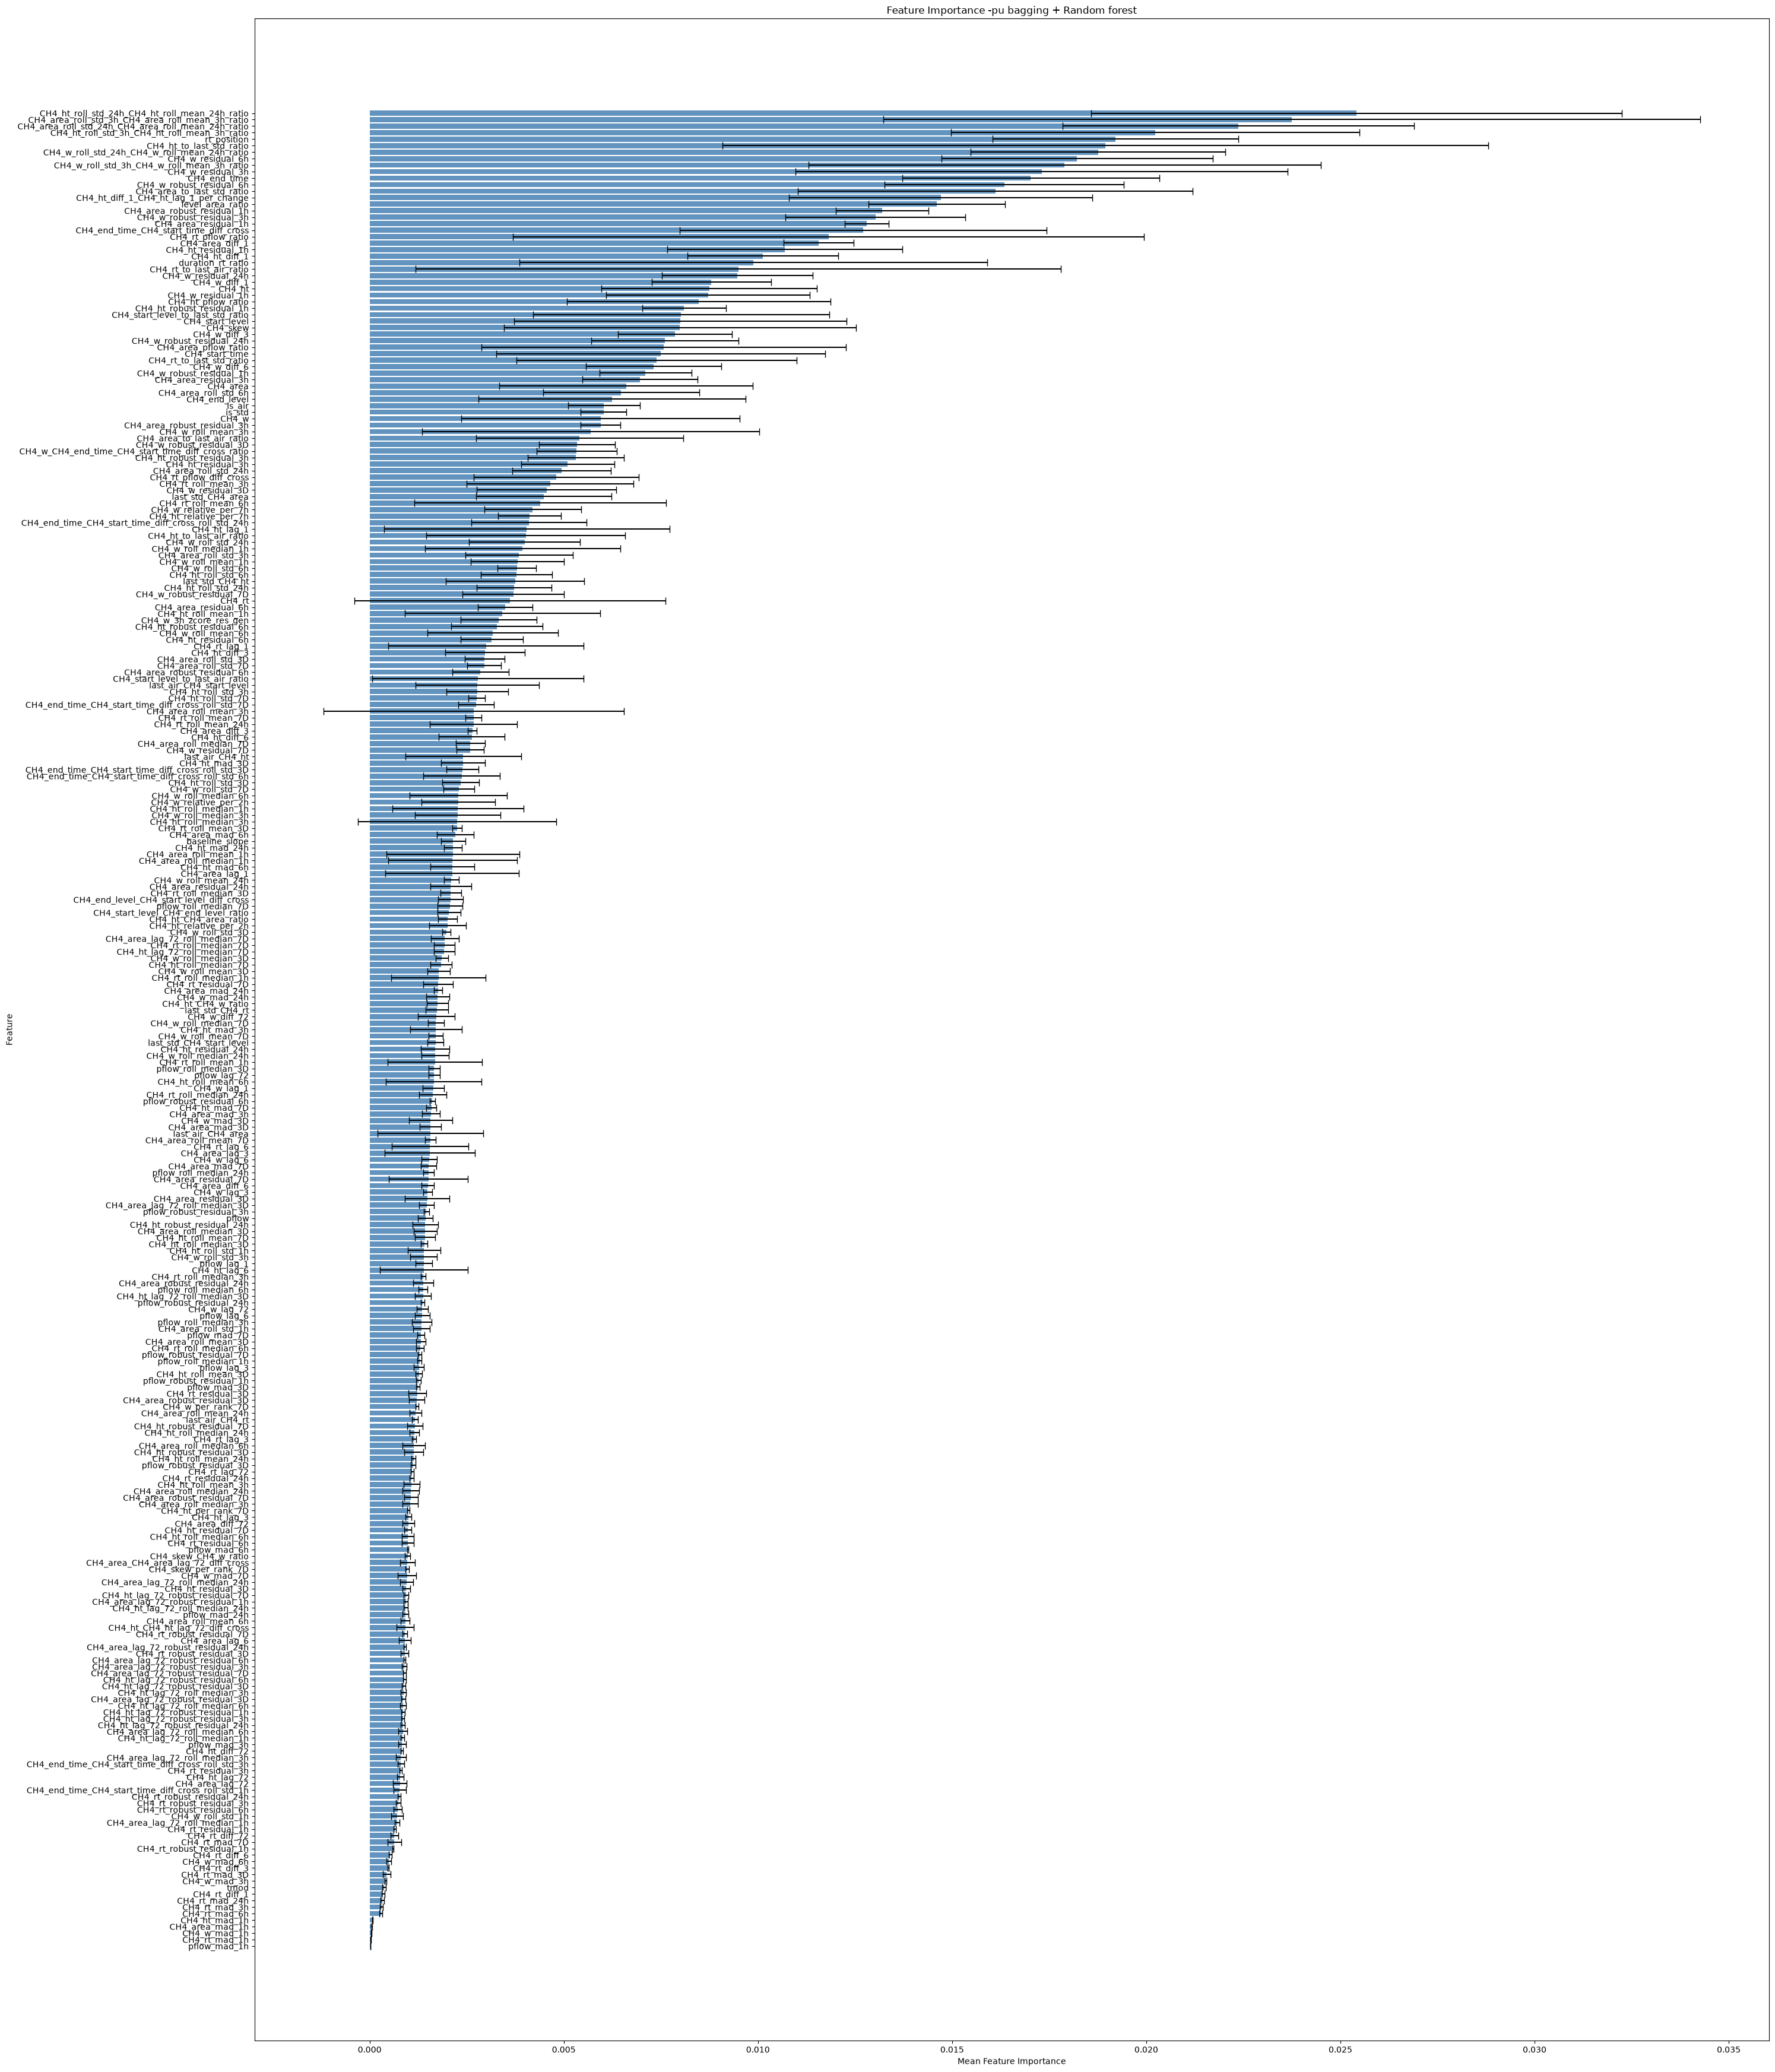

In [13]:
plot_df = (
    importance_summary.sort_values("importance_mean")
)
plt.figure(figsize=(30,35))

plt.barh(
    plot_df['Feature'],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"],
    capsize=4,
    color="steelblue",
    alpha=0.85
)

plt.xlabel("Mean Feature Importance")
plt.ylabel("Feature")
plt.title(f"Feature Importance -pu bagging + Random forest")
plt.tight_layout()
plt.show()

In [12]:
def bagging_rf(n_bags, X_train_final, y_train):
    pos_idx = np.flatnonzero(y_train.to_numpy() == 1)
    unl_idx = np.flatnonzero(y_train.to_numpy() == 0)

    # obtain the number of positive and unlabeled data
    print(f"Number of Bag: {n_bags}")
    number_pos = len(pos_idx)
    print("Positive:", len(pos_idx))
    print("Unlabeled:", len(unl_idx))

    rng = np.random.default_rng(42)

    feature_importances = []
    models = []

    for bag in range(n_bags):
        sampled_pos = pos_idx

        #select same number data of positive data from unlabeld data
        sampled_unl_idx = rng.choice(
            unl_idx,
            size=number_pos,
            replace=False
        )

        sampled_idx = np.concatenate([
            pos_idx,
            sampled_unl_idx
        ])


        rng.shuffle(sampled_idx)

        X_pu = X_train_final.iloc[sampled_idx]
        y_pu = y_train.iloc[sampled_idx]

        print(
            f"\n PU training data, Bag {bag +1}/{n_bags} "
            f"Positive = {(y_pu ==1).sum()}, "
            f"Unlabeled = {(y_pu == 0).sum()}"
        )

        base_rf = RandomForestClassifier(
            random_state=42
        )

        base_rf.fit(X_pu, y_pu)

        models.append(base_rf)

        feature_importances.append(
            base_rf.feature_importances_
        )

    importance_df = pd.DataFrame(
        feature_importances,
        columns=X_train_final.columns
    )
    importance_summary = pd.DataFrame({
        "Feature": X_train_final.columns,
        "importance_mean":importance_df.mean(axis=0),
        "importance_std": importance_df.std(axis=0),
        "importance_cv percent":(importance_df.std(axis=0) / importance_df.mean(axis=0))*100  #coefficient of variation
    }).sort_values(
        "importance_mean", ascending=False
        )

    rank_df = importance_df.rank(
        axis=1,
        ascending=False,
        method="average"
    ) # rank in every bag iter

    rank_summary = pd.DataFrame({
        "Feature": X_train_final.columns,
            "rank_mean":rank_df.mean(axis=0),
            "rank_std": importance_df.std(axis=0),
            "rank_cv percent":(importance_df.std(axis=0) / importance_df.mean(axis=0))*100  #coefficient of variation
        }).sort_values(
            "rank_mean"
            )
    return models, importance_summary, rank_summary
    


#### Bagging for 20 bags

In [15]:

models_10, importance_summary_10, rank_10 = bagging_rf(10, X_train_final, y_train)
models_20, importance_summary_20, rank_20 = bagging_rf(20, X_train_final, y_train)
models_30, importance_summary_30, rank_30 = bagging_rf(30, X_train_final, y_train)

Number of Bag: 10
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 6/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 7/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 8/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 9/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 10/10 Positive = 21442, Unlabeled = 21442
Number of Bag: 20
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/20 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/20 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/20 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/20 Positive = 21442, Unl

87 mins

=====

In [ ]:
os.makedirs('csv', exist_ok=True) 
importance_summary_10.to_csv("csv/importance_summary_10.csv", index=False)
importance_summary_20.to_csv("csv/importance_summary_20.csv", index=False)
importance_summary_30.to_csv("csv/importance_summary_30.csv", index=False)
rank_10.to_csv("csv/rank_10.csv", index=False)
rank_20.to_csv("csv/rank_20.csv", index=False)
rank_30.to_csv("csv/rank_30.csv", index=False)

NameError: name 'importance_summary_10' is not defined

In [13]:
importance_summary_10 = pd.read_csv("csv/importance_summary_10.csv")
importance_summary_20= pd.read_csv("csv/importance_summary_20.csv")
importance_summary_30= pd.read_csv("csv/importance_summary_30.csv")
rank_10 = pd.read_csv("csv/rank_10.csv")
rank_20 = pd.read_csv("csv/rank_20.csv")
rank_30 = pd.read_csv("csv/rank_30.csv")

### Visulize feature importance

In [14]:
importance_compare = pd.concat({
  
    "10 bag": importance_summary_10.set_index("Feature")["importance_mean"],
    "20 bag": importance_summary_20.set_index("Feature")["importance_mean"],
    "30 bag": importance_summary_30.set_index("Feature")["importance_mean"]
}, axis = 1)

importance_compare 

,10 bag,20 bag,30 bag
Feature,,,
CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio,0.028346,0.028839,0.028911
CH4_rt_to_last_air_ratio,0.024685,0.024762,0.025018
CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio,0.024435,0.024574,0.024644
CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio,0.019256,0.018751,0.018450
CH4_w_residual_6h,0.018787,0.017833,0.017674
duration_rt_ratio,0.018783,0.018802,0.018807
rt_position,0.018704,0.018388,0.018616
CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio,0.018622,0.018710,0.018696
CH4_ht_to_last_std_ratio,0.018453,0.018590,0.018577


28 above 0.001

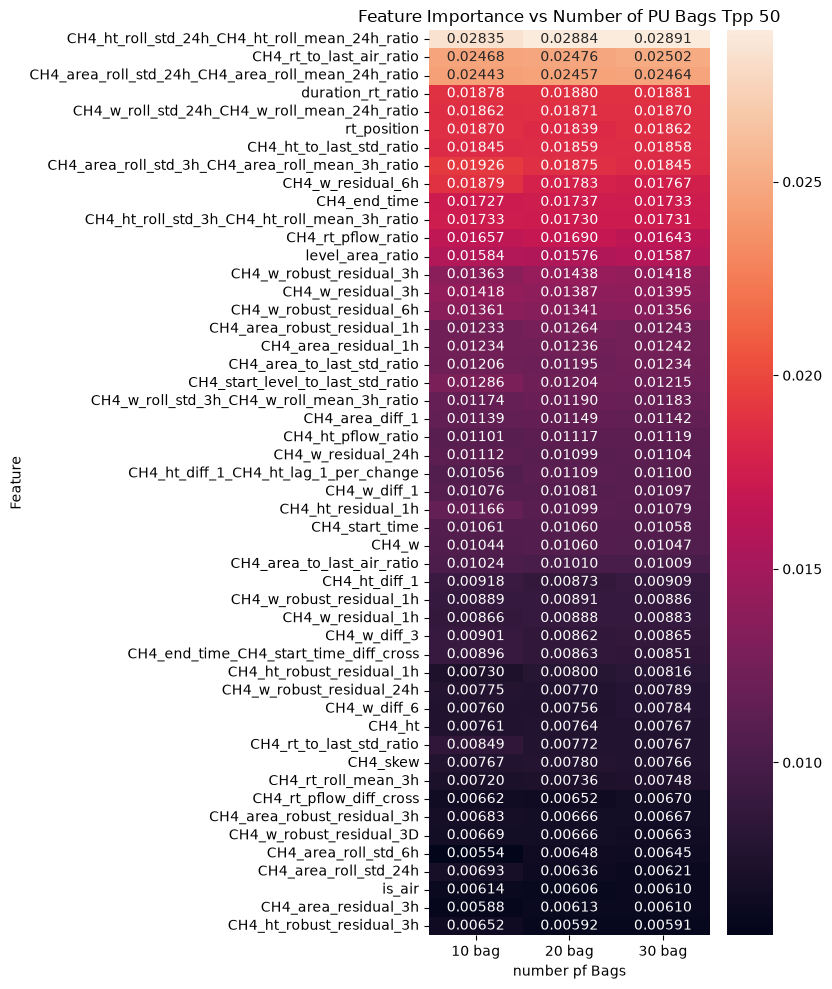

<Figure size 640x480 with 0 Axes>

In [15]:
top50 = importance_summary_30.head(50)["Feature"]
plot_data = importance_compare.loc[top50]

plt.figure(figsize=(8, 10))

sns.heatmap(
    plot_data,
    annot=True,
    fmt=".5f"
)

plt.xlabel("number pf Bags")
plt.ylabel("Feature")
plt.title("Feature Importance vs Number of PU Bags Tpp 50")
plt.tight_layout()
plt.show()

plt.savefig("img/Fea_imp10_30_compare.png")

### CV performance

In [16]:
cv_compare = pd.concat({
    "10 bag": importance_summary_10.set_index("Feature")["importance_cv percent"],
    "20 bag": importance_summary_20.set_index("Feature")["importance_cv percent"],
    "30 bag": importance_summary_30.set_index("Feature")["importance_cv percent"]
}, axis = 1)

cv_compare

,10 bag,20 bag,30 bag
Feature,,,
CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio,4.797020,5.942637,5.622964
CH4_rt_to_last_air_ratio,5.681659,5.207491,4.434128
CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio,5.443956,6.346108,6.662199
CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio,5.055383,5.816338,5.990582
CH4_w_residual_6h,19.520331,25.204622,25.329592
duration_rt_ratio,2.008486,1.831416,1.685729
rt_position,3.871774,5.786591,5.311696
CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio,10.839420,10.912712,9.637045
CH4_ht_to_last_std_ratio,2.588182,3.168295,3.357810


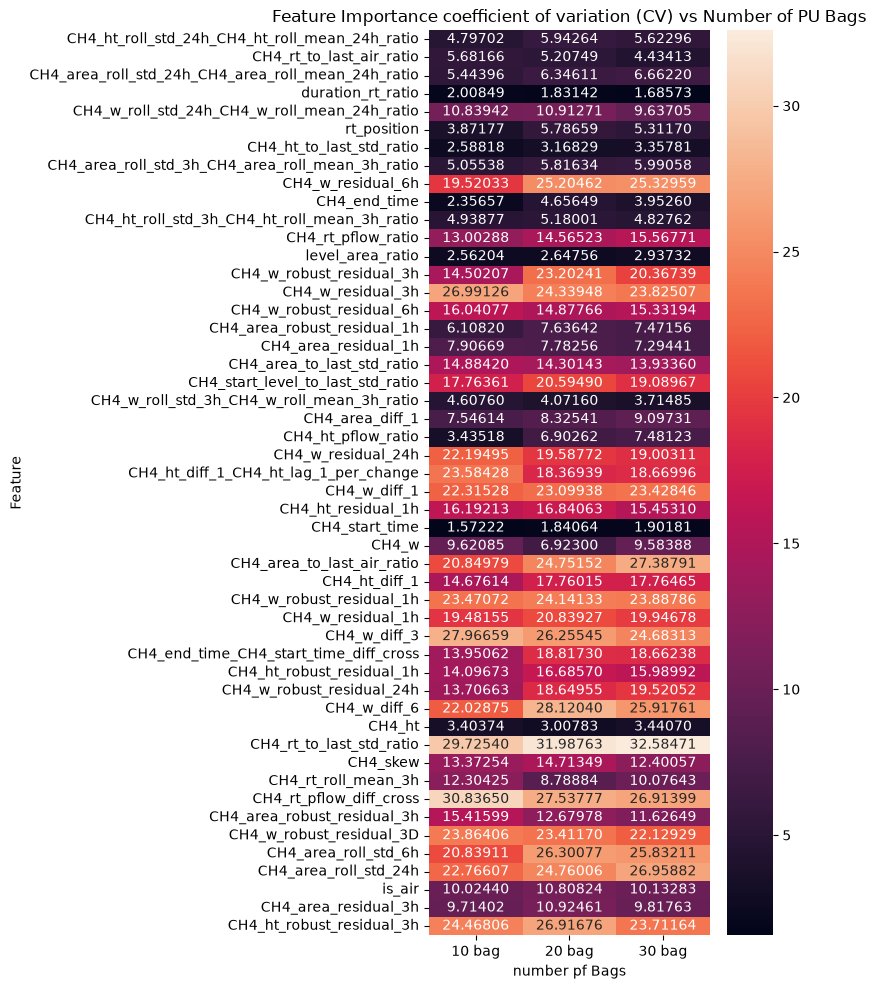

<Figure size 640x480 with 0 Axes>

In [17]:

plot_data = cv_compare.loc[top50]

plt.figure(figsize=(8, 10))

sns.heatmap(
    plot_data,
    annot=True,
    fmt=".5f"
)

plt.xlabel("number pf Bags")
plt.ylabel("Feature")
plt.title("Feature Importance coefficient of variation (CV) vs Number of PU Bags")
plt.tight_layout()
plt.show()

plt.savefig("img/Fea_imp10_30__cv_compare.png")

### Rank Compare

In [18]:
rank_compare = pd.concat({
    "10 bag": rank_10.set_index("Feature")["rank_mean"],
    "20 bag": rank_20.set_index("Feature")["rank_mean"],
    "30 bag": rank_30.set_index("Feature")["rank_mean"]
}, axis = 1)

rank_compare

,10 bag,20 bag,30 bag
Feature,,,
CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio,1.0,1.05,1.066667
CH4_rt_to_last_air_ratio,2.5,2.60,2.533333
CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio,2.8,2.65,2.666667
CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio,5.8,6.80,7.366667
duration_rt_ratio,6.4,6.40,6.200000
rt_position,6.9,7.40,6.666667
CH4_ht_to_last_std_ratio,7.2,7.05,7.033333
CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio,8.0,7.70,7.466667
CH4_w_residual_6h,8.8,10.55,10.966667


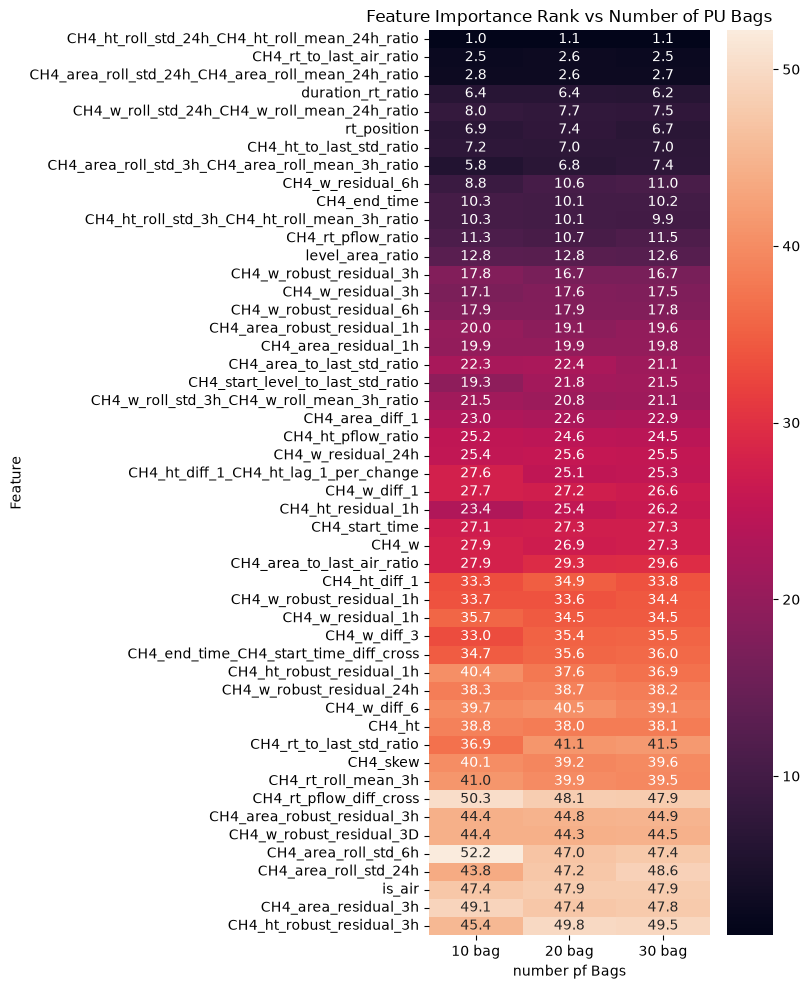

<Figure size 640x480 with 0 Axes>

In [19]:
plot_data = rank_compare.loc[top50]

plt.figure(figsize=(8, 10))

sns.heatmap(
    plot_data,
    annot=True,
    fmt=".1f"
)

plt.xlabel("number pf Bags")
plt.ylabel("Feature")
plt.title("Feature Importance Rank vs Number of PU Bags")
plt.tight_layout()
plt.show()

plt.savefig("img/Fea_imp5_30__rank_compare.png")

#### Compare them together



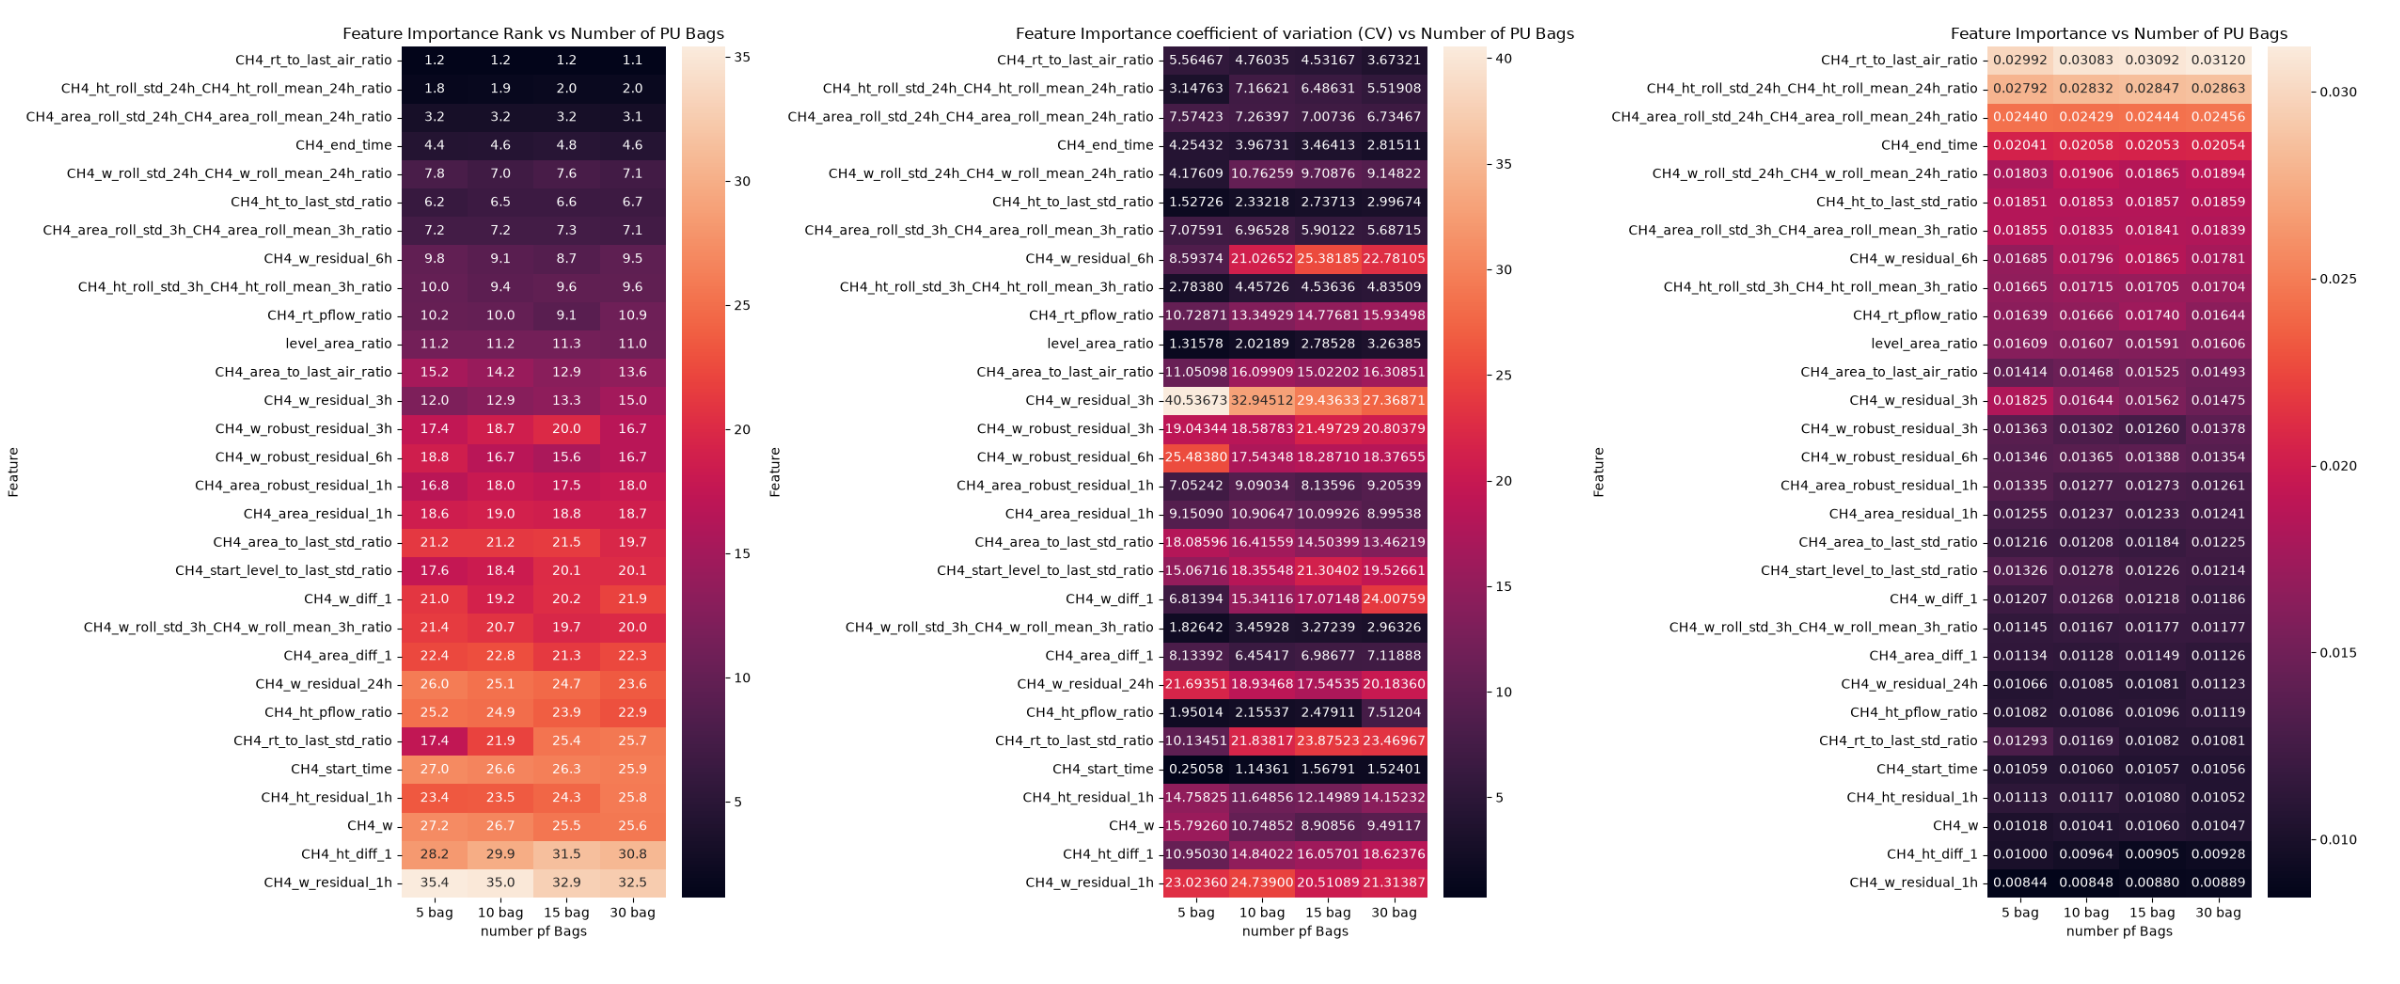

rank 的 top3 是基於mean feature importance 在30 bags
所以會看到6.7 在7.1上面

In [20]:
# top 30' feature
top50.tolist()

['CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio',
 'CH4_rt_to_last_air_ratio',
 'CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio',
 'duration_rt_ratio',
 'CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio',
 'rt_position',
 'CH4_ht_to_last_std_ratio',
 'CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio',
 'CH4_w_residual_6h',
 'CH4_end_time',
 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio',
 'CH4_rt_pflow_ratio',
 'level_area_ratio',
 'CH4_w_robust_residual_3h',
 'CH4_w_residual_3h',
 'CH4_w_robust_residual_6h',
 'CH4_area_robust_residual_1h',
 'CH4_area_residual_1h',
 'CH4_area_to_last_std_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio',
 'CH4_area_diff_1',
 'CH4_ht_pflow_ratio',
 'CH4_w_residual_24h',
 'CH4_ht_diff_1_CH4_ht_lag_1_per_change',
 'CH4_w_diff_1',
 'CH4_ht_residual_1h',
 'CH4_start_time',
 'CH4_w',
 'CH4_area_to_last_air_ratio',
 'CH4_ht_diff_1',
 'CH4_w_robust_residual_1h',
 'CH4_w_residual_1h',
 'CH4_w_diff_3',
 'CH4_end_time_CH

In [21]:
df_filter = pd.DataFrame({
    'importance':importance_compare['30 bag'],
    'cv': cv_compare['30 bag'],
    'rank':rank_compare['30 bag']
}).reset_index()


rule1_mask = ~((df_filter['rank'] > 50) & (df_filter['importance'] < 0.01))

rule2_mask = ~((df_filter['cv'] > 20.0) & (df_filter['rank'] > 50))

df_selected = df_filter[rule1_mask & rule2_mask].sort_values("rank")
candidate_features = df_selected['Feature'].head(50).tolist()

#print(f"Save faetures: {len(candidate_features)}")
#print("Top5", candidate_features[:5])


In [22]:
candidate_features

['CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio',
 'CH4_rt_to_last_air_ratio',
 'CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio',
 'duration_rt_ratio',
 'rt_position',
 'CH4_ht_to_last_std_ratio',
 'CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio',
 'CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio',
 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio',
 'CH4_end_time',
 'CH4_w_residual_6h',
 'CH4_rt_pflow_ratio',
 'level_area_ratio',
 'CH4_w_robust_residual_3h',
 'CH4_w_residual_3h',
 'CH4_w_robust_residual_6h',
 'CH4_area_robust_residual_1h',
 'CH4_area_residual_1h',
 'CH4_area_to_last_std_ratio',
 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_area_diff_1',
 'CH4_ht_pflow_ratio',
 'CH4_ht_diff_1_CH4_ht_lag_1_per_change',
 'CH4_w_residual_24h',
 'CH4_ht_residual_1h',
 'CH4_w_diff_1',
 'CH4_w',
 'CH4_start_time',
 'CH4_area_to_last_air_ratio',
 'CH4_ht_diff_1',
 'CH4_w_robust_residual_1h',
 'CH4_w_residual_1h',
 'CH4_w_diff_3',
 'CH4_end_time_CH

In [24]:
len(candidate_features)

50

=== Start ===
Number of Bag: 10
Positive: 18296
Unlabeled: 479128

 PU training data, Bag 1/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 2/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 3/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 4/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 5/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 6/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 7/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 8/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 9/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 10/10 Positive = 18296, Unlabeled = 18296
TOP K = 10 features | validation (PR-AUC): 0.4976
Number of Bag: 10
Positive: 18296
Unlabeled: 479128

 PU training data, Bag 1/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 2/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 3/10 Positive = 18296, Unla

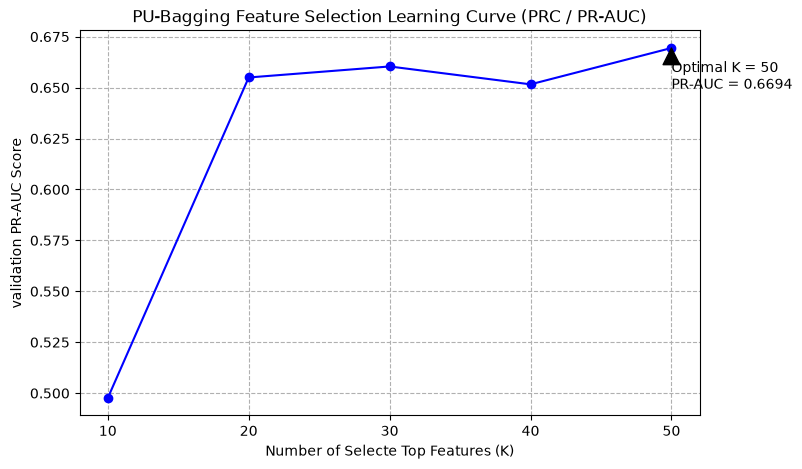

Final features and number: 50 
 ['CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio', 'CH4_rt_to_last_air_ratio', 'CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio', 'duration_rt_ratio', 'rt_position', 'CH4_ht_to_last_std_ratio', 'CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio', 'CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio', 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio', 'CH4_end_time', 'CH4_w_residual_6h', 'CH4_rt_pflow_ratio', 'level_area_ratio', 'CH4_w_robust_residual_3h', 'CH4_w_residual_3h', 'CH4_w_robust_residual_6h', 'CH4_area_robust_residual_1h', 'CH4_area_residual_1h', 'CH4_area_to_last_std_ratio', 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio', 'CH4_start_level_to_last_std_ratio', 'CH4_area_diff_1', 'CH4_ht_pflow_ratio', 'CH4_ht_diff_1_CH4_ht_lag_1_per_change', 'CH4_w_residual_24h', 'CH4_ht_residual_1h', 'CH4_w_diff_1', 'CH4_w', 'CH4_start_time', 'CH4_area_to_last_air_ratio', 'CH4_ht_diff_1', 'CH4_w_robust_residual_1h', 'CH4_w_residual_1h', 'CH4_w_diff_3', 'CH4_end_time_CH4_

In [26]:
from sklearn.metrics import average_precision_score
val_split_idx = int(len(X_train_final)*0.8)
X_tr = X_train_final.iloc[:val_split_idx]
y_tr = y_train.iloc[:val_split_idx]

X_val = X_train_final.iloc[val_split_idx:]
y_val = y_train.iloc[val_split_idx:]

k_candidates = np.arange(10, 60, 10)
k_list = [k for k in k_candidates if k <= len(candidate_features)]


val_prc_scores = []

print("=== Start ===")

for k in k_list:
    sub_features = candidate_features[:k]
    models, _, _ = bagging_rf(10, X_tr[sub_features], y_tr)

    val_preds = np.mean([m.predict_proba(X_val[sub_features])[:, 1] for m in models], axis=0)
    prc_auc= average_precision_score(y_val, val_preds)
    val_prc_scores.append(prc_auc)

    print(f"TOP K = {k:2d} features | validation (PR-AUC): {prc_auc:.4f}")

best_idx = np.argmax(val_prc_scores)
best_k = k_list[best_idx]

best_features = candidate_features[:best_k]

plt.figure(figsize=(8,5))
plt.plot(k_list, val_prc_scores, 'o-', color='blue', label='PR-AUC Score')


plt.annotate(
    f"Optimal K = {best_k}\nPR-AUC = {val_prc_scores[best_idx]:.4f}",
    xy = (best_k, val_prc_scores[best_idx]),
    xytext=(best_k, val_prc_scores[best_idx] - 0.02),
    arrowprops=dict(facecolor='black')
)


plt.title('PU-Bagging Feature Selection Learning Curve (PRC / PR-AUC)')
plt.xlabel("Number of Selecte Top Features (K)")
plt.ylabel("validation PR-AUC Score")
plt.xticks(k_list)
plt.grid(True, linestyle='--')
plt.show()
print(f'Final features and number:', best_k, "\n", best_features)

In [29]:
best_features[:30]

['CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio',
 'CH4_rt_to_last_air_ratio',
 'CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio',
 'duration_rt_ratio',
 'rt_position',
 'CH4_ht_to_last_std_ratio',
 'CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio',
 'CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio',
 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio',
 'CH4_end_time',
 'CH4_w_residual_6h',
 'CH4_rt_pflow_ratio',
 'level_area_ratio',
 'CH4_w_robust_residual_3h',
 'CH4_w_residual_3h',
 'CH4_w_robust_residual_6h',
 'CH4_area_robust_residual_1h',
 'CH4_area_residual_1h',
 'CH4_area_to_last_std_ratio',
 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_area_diff_1',
 'CH4_ht_pflow_ratio',
 'CH4_ht_diff_1_CH4_ht_lag_1_per_change',
 'CH4_w_residual_24h',
 'CH4_ht_residual_1h',
 'CH4_w_diff_1',
 'CH4_w',
 'CH4_start_time',
 'CH4_area_to_last_air_ratio']

==================================

In [ ]:
from sklearn.metrics import average_precision_score
val_split_idx = int(len(X_train_final)*0.8)
X_tr = X_train_final.iloc[:val_split_idx]
y_tr = y_train.iloc[:val_split_idx]

X_val = X_train_final.iloc[val_split_idx:]
y_val = y_train.iloc[val_split_idx:]

k_candidates = np.arange(10, 60, 10)
k_list = [k for k in k_candidates if k <= len(candidate_features)]


val_prc_scores = []

print("=== Start ===")

for k in k_list:
    sub_features = candidate_features[:k]
    models, _, _ = bagging_rf(10, X_tr[sub_features], y_tr)

    val_preds = np.mean([m.predict_proba(X_val[sub_features])[:, 1] for m in models], axis=0)
    prc_auc= average_precision_score(y_val, val_preds)
    val_prc_scores.append(prc_auc)

    print(f"TOP K = {k:2d} features | validation (PR-AUC): {prc_auc:.4f}")

best_idx = np.argmax(val_prc_scores)
best_k = k_list[best_idx]

best_features = candidate_features[:best_k]

plt.figure(figsize=(8,5))
plt.plot(k_list, val_prc_scores, 'o-', color='blue', label='PR-AUC Score')


plt.annotate(
    f"Optimal K = {best_k}\nPR-AUC = {val_prc_scores[best_idx]:.4f}",
    xy = (best_k, val_prc_scores[best_idx]),
    xytext=(best_k, val_prc_scores[best_idx] - 0.02),
    arrowprops=dict(facecolor='black')
)


plt.title('PU-Bagging Feature Selection Learning Curve (PRC / PR-AUC)')
plt.xlabel("Number of Selecte Top Features (K)")
plt.ylabel("validation PR-AUC Score")
plt.xticks(k_list)
plt.grid(True, linestyle='--')
plt.show()
print(f'Final features and number:', best_k, "\n", best_features)

=============

plot_df = (
    importance_summary_30.sort_values("importance_mean")
)
plt.figure(figsize=(20,35))

plt.barh(
    plot_df['Feature'],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"],
    capsize=6,
    color="steelblue",
    alpha=0.85
)

plt.xlabel("Mean Feature Importance")
plt.ylabel("Feature")
plt.yticks(fontsize=8)
plt.title(f"Feature Importance -pu bagging (30 bags)+ Random forest")
plt.tight_layout()
plt.show()

THE PREVIOUS　Feature we use
feature_ml = ['level_area_ratio',
 'CH4_ht_to_last_std_ratio',
 'CH4_area_mad_3h',
 'CH4_ht_roll_std_1h',
 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio',
 'CH4_ht',
 'CH4_skew',
 'CH4_area_to_last_std_ratio',
 'CH4_ht_roll_mean_1h',
 'CH4_area_roll_std_1h',
 'CH4_ht_pflow_ratio',
 'CH4_ht_mad_3h',
 'CH4_w_residual_3h',
 'CH4_w_residual_1h',
 'CH4_w_diff_1',
 'CH4_rt_to_last_std_ratio',
 'CH4_w_roll_std_1h',
 'CH4_area_pflow_ratio',
 'CH4_w_robust_residual_1h',
 'CH4_ht_roll_median_1h',
 'CH4_rt_to_last_air_ratio',
 'last_std_CH4_ht',
 'CH4_w_robust_residual_6h',
 'CH4_w_roll_mean_1h',
 'CH4_w_residual_6h',
 'CH4_w_roll_median_1h',
 'CH4_area_roll_mean_1h',
 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio',
 'CH4_w_roll_std_3h',
 'CH4_rt_roll_mean_1h',]

CURRENT USE:['CH4_rt_to_last_air_ratio',
 'CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio',
 'CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio',
 'CH4_end_time',
 'CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio',
 'CH4_ht_to_last_std_ratio',
 'CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio',
 'CH4_w_residual_6h',
 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio',
 'CH4_rt_pflow_ratio',
 'level_area_ratio',
 'CH4_area_to_last_air_ratio',
 'CH4_w_residual_3h',
 'CH4_w_robust_residual_3h',
 'CH4_w_robust_residual_6h',
 'CH4_area_robust_residual_1h',
 'CH4_area_residual_1h',
 'CH4_area_to_last_std_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_w_diff_1',
 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio',
 'CH4_area_diff_1',
 'CH4_w_residual_24h',
 'CH4_ht_pflow_ratio',
 'CH4_rt_to_last_std_ratio',
 'CH4_start_time',
 'CH4_ht_residual_1h',
 'CH4_w',
 'CH4_ht_diff_1',
 'CH4_w_residual_1h']